# Backprop Ninja

## The Intials

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
char = sorted(list(set(''.join(words))))
stoi = { x:i+1 for i, x in enumerate(char)}
stoi['.'] = 0
itos = {x:i for i,x in stoi.items()}
print(stoi)
itos
vocab_size = len(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [36]:
block_size = 3



def build_dataset(words):
    X, Y  = [], []
    for w in words:
        ch = w+'.'
        context = [0] *block_size
        # print(ch)
        for i in ch:
            # print(i)
            ix = stoi[i]
            # print(ix)
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X= torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182538, 3]) torch.Size([182538])
torch.Size([22941, 3]) torch.Size([22941])
torch.Size([22674, 3]) torch.Size([22674])


In [37]:
def cmp(s, dt, t):
    ex = torch.all(dt ==t.grad).item()
    # print(ex)
    app = torch.allclose(dt, t.grad)
    # print(app)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate : {str(app):5s} | maxdiff: {maxdiff}')

In [38]:
n_embd = 10
n_hidden = 64
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(vocab_size, n_embd)
W1 = torch.randn(n_embd*block_size, n_hidden )*((5/3)/ (n_embd * block_size)**0.5)
b1 = (torch.rand(n_hidden))*0.1
W2 = torch.randn(n_hidden, vocab_size)*0.1
b2 = torch.randn(vocab_size)*0.1
bngain = torch.ones((1,n_hidden))*0.1 + 0.1
bnbias = torch.zeros((1,n_hidden))*0.1
# bnmean_running = torch.ones(1, n_hidden)
# bnstd_running = torch.zeros(1, n_hidden)
parameters = [C, W1, W2, b1, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

4137


In [ ]:
batch_size = 32
n = batch_size
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hprebn =  embcat@W1 +b1
# hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True)
bnmeani = 1/n*hprebn.mean(0, keepdim = True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim = True)
bnvar_inv = (bnvar +1e-5) **-0.5
bnraw = bndiff*bnvar_inv
hpreact = bngain*bnraw + bnbias

h = torch.tanh(hpreact)

logits = h @ W2 +b2

logit_maxes = logits.max(1, keepdim = True).values
lidx = logits.max(1, keepdim = True).indices
norm_logits = logits - logit_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim= True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

for p in parameters:
    p.grad = None

for t in [logprobs, probs, counts, counts_sum,
         counts_sum_inv, norm_logits, logit_maxes, logits, h, 
         hpreact, bnraw, bnvar_inv, bndiff2, bndiff, hprebn, bnmeani,
          bnvar , embcat,emb]:
    t.retain_grad()
loss.backward()
loss


tensor(3.3716, grad_fn=<NegBackward0>)

In [53]:
# probs.shape
# counts.shape
# counts_sum_inv.shape
bndiff2.shape

torch.Size([32, 64])

In [64]:
# Manual backpropagation
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n

dprobs = (1.0 / probs) * dlogprobs

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
cmp('counts', dcounts, counts)

dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv

dcounts += torch.ones_like(counts) * dcounts_sum
cmp('counts', dcounts, counts)

dnorm_logits = counts * dcounts

dlogits = dnorm_logits.clone()
cmp('logits', dlogits, logits)

dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dx = torch.zeros_like(logits)
dx[range(32), lidx.squeeze(1)] = 1.0
dlogits += dx*dlogit_maxes
cmp('logits', dlogits, logits)
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1-h**2)*dh
dbngain = (bnraw*dhpreact).sum(0, keepdim = True)
dbnraw = bngain*dhpreact
dbnbias = (dhpreact).sum(0, keepdim = True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim = True)
cmp('bndiff', dbndiff, bndiff)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5)*dbnvar_inv
dbndiff2 = (1/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += 2*bndiff*dbndiff2
cmp('bndiff', dbndiff, bndiff)


counts          | exact: False | approximate : False | maxdiff: 0.0018609465332701802
counts          | exact: True  | approximate : True  | maxdiff: 0.0
logits          | exact: False | approximate : True  | maxdiff: 4.6566128730773926e-09
logits          | exact: True  | approximate : True  | maxdiff: 0.0
bndiff          | exact: False | approximate : False | maxdiff: 0.0005366093828342855
bndiff          | exact: True  | approximate : True  | maxdiff: 0.0


In [65]:
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('normlogits', dnorm_logits, norm_logits)
cmp('logits', dlogits, logits)
cmp('logits_maxes', dlogit_maxes, logit_maxes)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('tanh', dhpreact, hpreact)
cmp('bngain', dbngain,bngain)
cmp('bnbias', dbnbias,bnbias)
cmp('bnraw', dbnraw,bnraw)
# cmp('bndiff', dbndiff, bndiff)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)

logprobs        | exact: True  | approximate : True  | maxdiff: 0.0
probs           | exact: True  | approximate : True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate : True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate : True  | maxdiff: 0.0
counts          | exact: True  | approximate : True  | maxdiff: 0.0
normlogits      | exact: True  | approximate : True  | maxdiff: 0.0
logits          | exact: True  | approximate : True  | maxdiff: 0.0
logits_maxes    | exact: True  | approximate : True  | maxdiff: 0.0
h               | exact: True  | approximate : True  | maxdiff: 0.0
W2              | exact: True  | approximate : True  | maxdiff: 0.0
b2              | exact: True  | approximate : True  | maxdiff: 0.0
tanh            | exact: True  | approximate : True  | maxdiff: 0.0
bngain          | exact: True  | approximate : True  | maxdiff: 0.0
bnbias          | exact: True  | approximate : True  | maxdiff: 0.0
bnraw           | exact: True  | approximate : T

In [42]:
# print("\nh\n",h.shape,"\ndlogits\n",dlogits.shape,"\nW2\n",  W2.shape, "\nb2\n",b2.shape)
bngain.shape, bnraw.shape, bnbias.shape
bnvar_inv.shape, bndiff.shape,bnraw.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [43]:
dbnvar.shape, bnvar.shape

(torch.Size([1, 64]), torch.Size([1, 64]))

In [44]:
print(torch.all(dbnvar== dbnvar).item())

True


In [47]:
dbnbias.shape, bnraw.shape, dbnbias.shape, dhpreact.shape
dbnvar_inv.shape, dbndiff.shape, dbnraw.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [48]:
# logits = h @ W2 +b2
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
db2.shape

torch.Size([27])

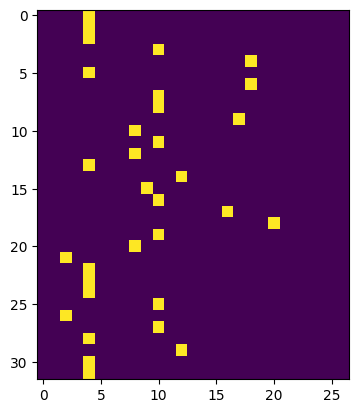

In [49]:
plt.imshow(dx)

logprobs        | exact: True  | approximate : True  | maxdiff: 0.0
probs           | exact: True  | approximate : True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate : True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate : True  | maxdiff: 0.0
counts          | exact: True  | approximate : True  | maxdiff: 0.0
normlogits      | exact: True  | approximate : True  | maxdiff: 0.0
logits          | exact: True  | approximate : True  | maxdiff: 0.0
logits_maxes    | exact: True  | approximate : True  | maxdiff: 0.0
h               | exact: True  | approximate : True  | maxdiff: 0.0
W2              | exact: True  | approximate : True  | maxdiff: 0.0
b2              | exact: True  | approximate : True  | maxdiff: 0.0
tanh            | exact: True  | approximate : True  | maxdiff: 0.0
bngain          | exact: True  | approximate : True  | maxdiff: 0.0
bnbias          | exact: True  | approximate : True  | maxdiff: 0.0
bnraw           | exact: True  | approximate : T

In [ ]:
dbnvar, bnvar.shape

(torch.Size([1, 64]), torch.Size([1, 64]))

In [15]:
probs.shape
logprobs.shape
counts.shape
dcounts.shape
# counts_sum_inv.shape
bnvar.shape, dbnvar.shape

(torch.Size([1, 64]), torch.Size([1, 64]))

In [ ]:
logits.max(1, keepdim = True)

torch.return_types.max(
values=tensor([[0.4787],
        [0.4104],
        [0.3651],
        [0.3651],
        [0.3658],
        [0.3028],
        [0.2604],
        [0.3651],
        [0.5246],
        [0.4643],
        [0.4904],
        [0.2919],
        [0.3286],
        [0.4483],
        [0.4726],
        [0.3651],
        [0.2419],
        [0.2786],
        [0.3288],
        [0.3651],
        [0.2781],
        [0.3350],
        [0.3475],
        [0.3097],
        [0.3651],
        [0.3214],
        [0.4918],
        [0.3079],
        [0.4963],
        [0.2816],
        [0.5277],
        [0.2806]], grad_fn=<MaxBackward0>),
indices=tensor([[ 7],
        [25],
        [ 0],
        [ 0],
        [ 0],
        [24],
        [25],
        [ 0],
        [ 2],
        [24],
        [24],
        [23],
        [24],
        [24],
        [23],
        [ 0],
        [24],
        [ 0],
        [ 5],
        [ 0],
        [24],
        [ 0],
        [ 0],
        [23],
        [ 0],
        [

In [ ]:
dlogit_maxes

tensor([[-9.3132e-10],
        [-1.3970e-09],
        [ 4.6566e-10],
        [ 2.3283e-09],
        [ 7.2177e-09],
        [ 3.4925e-09],
        [ 3.0268e-09],
        [-3.2596e-09],
        [-5.1223e-09],
        [-9.3132e-10],
        [-2.7940e-09],
        [-3.9581e-09],
        [-1.8626e-09],
        [-1.3970e-09],
        [-1.3970e-09],
        [ 4.6566e-10],
        [ 3.2596e-09],
        [ 3.0268e-09],
        [ 2.5611e-09],
        [ 2.3283e-09],
        [ 1.3970e-09],
        [ 2.3283e-10],
        [ 1.8626e-09],
        [-3.2596e-09],
        [ 1.3970e-09],
        [ 1.3970e-09],
        [-4.1910e-09],
        [ 0.0000e+00],
        [-9.3132e-10],
        [ 0.0000e+00],
        [-4.6566e-10],
        [ 6.2864e-09]], grad_fn=<SumBackward1>)

In [ ]:
logit_maxes

tensor([[0.4787],
        [0.4104],
        [0.3651],
        [0.3651],
        [0.3658],
        [0.3028],
        [0.2604],
        [0.3651],
        [0.5246],
        [0.4643],
        [0.4904],
        [0.2919],
        [0.3286],
        [0.4483],
        [0.4726],
        [0.3651],
        [0.2419],
        [0.2786],
        [0.3288],
        [0.3651],
        [0.2781],
        [0.3350],
        [0.3475],
        [0.3097],
        [0.3651],
        [0.3214],
        [0.4918],
        [0.3079],
        [0.4963],
        [0.2816],
        [0.5277],
        [0.2806]], grad_fn=<MaxBackward0>)

In [ ]:
dlogit_maxes

tensor([[-9.3132e-10],
        [-1.3970e-09],
        [ 4.6566e-10],
        [ 2.3283e-09],
        [ 7.2177e-09],
        [ 3.4925e-09],
        [ 3.0268e-09],
        [-3.2596e-09],
        [-5.1223e-09],
        [-9.3132e-10],
        [-2.7940e-09],
        [-3.9581e-09],
        [-1.8626e-09],
        [-1.3970e-09],
        [-1.3970e-09],
        [ 4.6566e-10],
        [ 3.2596e-09],
        [ 3.0268e-09],
        [ 2.5611e-09],
        [ 2.3283e-09],
        [ 1.3970e-09],
        [ 2.3283e-10],
        [ 1.8626e-09],
        [-3.2596e-09],
        [ 1.3970e-09],
        [ 1.3970e-09],
        [-4.1910e-09],
        [ 0.0000e+00],
        [-9.3132e-10],
        [ 0.0000e+00],
        [-4.6566e-10],
        [ 6.2864e-09]], grad_fn=<SumBackward1>)